## RADIAL RADAR Vehicle Detection

### SSM Model

X(k+1) = AX(k) + BU(k) --> U(k) is the radar cube at timeframe k
Y(k+1) = CX(k+1) + DU(k)   --> Some output

#### SSM One step

In [1]:
import torch
import torch.nn as nn

class RadarSSMEncoder(nn.Module):
    def __init__(self,
                 num_range_bins=512,
                 num_rx=32,
                 state_dim=128,
                 out_dim=128, 
                 dt = 0.5/(512*256)):
        """
        num_range_bins × num_rx = feature_dim per chirp step
        state_dim = dimension of hidden state X
        out_dim   = dimension of output Y per step
        """
        super().__init__()

        self.feature_dim = num_range_bins * num_rx
        self.state_dim   = state_dim
        self.out_dim     = out_dim
        self.dt = dt

        # optional input projection
        self.in_proj = nn.Linear(self.feature_dim, state_dim)
        self.SiLU = nn.SiLU()

        # parameter for stable A: A = -Q Q^T ⇒ eigenvalues ≤ 0
        self.Q = nn.Parameter(torch.randn(state_dim, state_dim))

        # other SSM matrices (you can of course re-param these too)
        self.B = nn.Parameter(torch.randn(state_dim, state_dim))
        self.C = nn.Parameter(torch.randn(out_dim,   state_dim))
        self.D = nn.Parameter(torch.randn(out_dim,   state_dim))

    def forward(self, radar_frame):
        """
        radar_frame: (B, 512, 256, 16)
          B = batch size, 512 = #range bins, 256 = #chirps (time steps), 16 = rx channels
        Returns:
          Y:        (B, 256, out_dim)  per-step outputs
          X_states: (B, 256, state_dim) per-step hidden states
        """
        B, R, T, C = radar_frame.shape
        # flatten range×rx → features
        U = radar_frame.permute(0,2,1,3).reshape(B, T, self.feature_dim)

        # build stable A
        A_c = -self.Q @ self.Q.t()  # (state_dim, state_dim)
        A = torch.matrix_exp(A_c * self.dt)
        B_mat = self.B
        C_mat = self.C
        D_mat = self.D

        # initial hidden state X(0)=0
        X = torch.zeros(B, self.state_dim, device=radar_frame.device)
        X_steps = []
        Y_steps = []

        for k in range(T):
            # U(k) → (B, feature_dim) → project to (B, state_dim)
            u_k = self.in_proj(U[:,k,:])
            u_k = self.SiLU(u_k)

            # X(k+1) = A X(k) + B U(k)
            X = X @ A.t() + u_k @ B_mat.t()

        #     # Y(k+1) = C X(k+1) + D U(k)
        #     y_k = X @ C_mat.t() + u_k @ D_mat.t()

        #     X_steps.append(X)
        #     Y_steps.append(y_k)
        y_k = X @ C_mat.t() + u_k @ D_mat.t()
        # # stack along time dimension
        # Y        = torch.stack(Y_steps, dim=1)   # (B, T, out_dim)
        # X_states = torch.stack(X_steps, dim=1)   # (B, T, state_dim)
        # return Y, X_states
        return y_k, X
    


#### SSM Single step vectorized

In [ ]:
import torch
import torch.nn as nn

class FastRadarSSMEncoder(nn.Module):
    def __init__(self,
                 num_range_bins=512,
                 num_rx=32,
                 state_dim=128,
                 out_dim=128,
                 dt=0.5/(256)):
        super().__init__()
        self.feature_dim = num_range_bins * num_rx
        self.state_dim   = state_dim
        self.out_dim     = out_dim
        self.dt          = dt

        # project + nonlinearity
        self.in_proj = nn.Linear(self.feature_dim, state_dim)
        self.act     = nn.SiLU()

        # continuous‐time generator
        self.Q = nn.Parameter(torch.randn(state_dim, state_dim))

        # SSM matrices
        self.B = nn.Parameter(torch.randn(state_dim, state_dim))
        self.C = nn.Parameter(torch.randn(out_dim,   state_dim))
        self.D = nn.Parameter(torch.randn(out_dim,   state_dim))

    def forward(self, radar_frame):
        # radar_frame: (B, 512, 256, 32)
        B, R, T, C = radar_frame.shape

        # 1) reshape & project ALL timesteps at once
        U = radar_frame.permute(0,2,1,3).reshape(B, T, self.feature_dim)
        U_flat      = U.reshape(-1, self.feature_dim)             # (B*T, feat)
        U_proj_flat = self.act(self.in_proj(U_flat))             # (B*T, state_dim)
        U_proj      = U_proj_flat.reshape(B, T, self.state_dim)  # (B, T, state_dim)

        # 2) build discrete A and pre‐transpose
        A   = torch.matrix_exp((-self.Q @ self.Q.t()) * self.dt)  # (S, S)
        A_t = A.t()
        B_t = self.B.t()
        C_t = self.C.t()  # (state_dim, out_dim)
        D_t = self.D.t()  # (state_dim, out_dim)

        # 3) loop only to update X
        X = torch.zeros(B, self.state_dim, device=radar_frame.device)
        X_steps = []
        for k in range(T):
            x = X @ A_t + U_proj[:,k,:] @ B_t
            X_steps.append(x)
            X = x

        # 4) stack X_states once
        X_states = torch.stack(X_steps, dim=1)  # (B, T, state_dim)

        # 5) vectorized Y: (B, T, state_dim) @ (state_dim, out_dim)
        Y = X_states @ C_t + U_proj @ D_t       # (B, T, out_dim)

        return Y, X_states


#### Segmentation Decoder

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SSMDecoder(nn.Module):
    def __init__(self,
                 state_dim: int = 128,
                 hidden_dim: int = 256,
                 num_classes: int = 1,
                 out_h: int = 128,
                 out_w: int = 225):
        """
        Decoder that takes the SSM state sequence X_states (B, T, state_dim)
        and produces a segmentation map of shape (B, num_classes, out_h, out_w).
        We use only the final state X_states[:, -1, :].
        """
        super().__init__()
        self.out_h = out_h
        self.out_w = out_w

        # project the final state into a small feature map (8×8 spatial)
        self.fc = nn.Linear(state_dim, hidden_dim * 8 * 8)

        # a few conv layers to refine
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim // 2),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden_dim // 2, hidden_dim // 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim // 4),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden_dim // 4, num_classes, kernel_size=1)
        )

    def forward(self, X_states: torch.Tensor) -> torch.Tensor:
        """
        Args:
          X_states: (B, T, state_dim)  from your SSM encoder
        Returns:
          seg_map: (B, num_classes, out_h, out_w)
        """
        # take only the final time‐step state
        x = X_states[:, -1, :]                  # (B, state_dim)
        B = x.size(0)

        # project to a small spatial map
        feat = self.fc(x)                       # (B, hidden_dim*8*8)
        feat = feat.view(B, -1, 8, 8)           # (B, hidden_dim, 8, 8)

        # refine with convs
        feat = self.conv_blocks(feat)           # (B, num_classes, 8, 8)

        # upsample to desired output size
        seg_map = F.interpolate(
            feat,
            size=(self.out_h, self.out_w),
            mode='bilinear',
            align_corners=False
        )                                       # (B, num_classes, out_h, out_w)

        return seg_map


#### State Predictive Modeling

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

class StatePredictor(nn.Module):
    def __init__(self, 
                 state_dim: int = 128, 
                 hidden_dim: int = 256, 
                 num_hidden_layers: int = 2, 
                 activation: nn.Module = nn.ReLU):
        """
        MLP that maps current state X_t (state_dim) → predicted next state X_{t+1} (state_dim).
        """
        super().__init__()
        layers = []
        in_dim = state_dim
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(activation(inplace=True))
            in_dim = hidden_dim
        layers.append(nn.Linear(hidden_dim, state_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
          x: (B, state_dim) or (state_dim,) tensor of current states
        Returns:
          x_pred: same shape as x, predicted next states
        """
        x = x[:, -1, :] # taking just the final state
        # if it’s given as (B, state_dim, 1), we can squeeze:
        if x.dim() == 3 and x.size(-1) == 1:
            x = x.squeeze(-1)
        return self.net(x)

#### Dataloader helper functions

In [5]:
from DBReader import SyncReader
from DBReader.SensorsReaders import CANDecoder
import matplotlib.pyplot as plt
import numpy as np

def get_radar_cube(sample):

    numSamplePerChirp = 512
    numRxPerChip = 4
    numChirps = 256
    numRxAnt = 16
    numTxAnt = 12
    numReducedDoppler = 16
    numChirpsPerLoop = 16
    
    adc0 = sample['radar_ch0']['data']
    adc1 = sample['radar_ch1']['data']
    adc2 = sample['radar_ch2']['data']
    adc3 = sample['radar_ch3']['data']

    frame0 = np.reshape(adc0[0::2] + 1j*adc0[1::2], (numSamplePerChirp,numRxPerChip, numChirps), order ='F').transpose((0,2,1))   
    frame1 = np.reshape(adc1[0::2] + 1j*adc1[1::2], (numSamplePerChirp,numRxPerChip, numChirps), order ='F').transpose((0,2,1))   
    frame2 = np.reshape(adc2[0::2] + 1j*adc2[1::2], (numSamplePerChirp,numRxPerChip, numChirps), order ='F').transpose((0,2,1))   
    frame3 = np.reshape(adc3[0::2] + 1j*adc3[1::2], (numSamplePerChirp,numRxPerChip, numChirps), order ='F').transpose((0,2,1))   
    radar_frame = np.concatenate([frame3,frame0,frame1,frame2],axis=2)

    # radar_frame_mag = np.abs(radar_frame)
    radar_frame_norm = radar_frame / (2**12) # np.std(radar_frame_mag)

    frame_ri = np.concatenate([radar_frame_norm.real, radar_frame_norm.imag], axis=2) 

    return frame_ri

def get_pointcloud(sample):

    def ConpensateLayerAngle(pcl,index,sensor_height):
    
        offset=0
        if(index%2==0):
            offset = np.deg2rad(.6)

        x = pcl[:,4] * np.cos(pcl[:,5]+offset) * np.cos(pcl[:,6])
        y = pcl[:,4] * np.cos(pcl[:,5]+offset) * np.sin(pcl[:,6])
        z = pcl[:,4] * np.sin(pcl[:,5]+offset) + sensor_height
        
        pcl[:,0] = x
        pcl[:,1] = y
        pcl[:,2] = z
    
        return pcl

    pts = sample['scala']['data']
    pts = ConpensateLayerAngle(pts,sample['scala']['sample_number'],0.42)[:,:3]

    return pts

def get_image(sample):
    return sample['camera']['data']

#### DataLoader

In [6]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image  # or use PIL.Image.open + transforms
import torch.nn.functional as F

class RadarSegmentationDataset(Dataset):
    def __init__(self,
                 csv_path: str,
                 data_root: str = "data_raw_sequences",
                 freespace_dir: str = "radar_Freespace",
                 transforms=None,
                 sensor_silent: bool = True):
        """
        Args:
          csv_path:        path to labels.csv
          data_root:       root folder containing each sequence folder
          freespace_subdir: name of the folder inside each seq containing freespace masks
          transforms:      optional transforms to apply to the mask (e.g. ToTensor)
          sensor_silent:   pass to SyncReader to suppress prints
        """
        self.df = pd.read_csv(csv_path)
        valid_rows = []
        # group by sequence, drop last index in each
        for seq_name, group in self.df.groupby("dataset"):
            max_idx = group["index"].max()
            valid_rows.append(group[group["index"] < max_idx])
        self.df = pd.concat(valid_rows).reset_index(drop=True)
        
        self.data_root = data_root
        self.freespace_dir = freespace_dir
        self.transforms = transforms
        self.readers = {}
        self.sensor_silent = sensor_silent

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        seq_name  = row["dataset"]
        numSample = int(row["numSample"])
        frame_idx = int(row["index"])

        # 1) ensure reader for this sequence
        if seq_name not in self.readers:
            seq_path = os.path.join(self.data_root, seq_name)
            self.readers[seq_name] = SyncReader(seq_path, silent=self.sensor_silent)
        db = self.readers[seq_name]

        # 2) load radar cube for this frame and next frame
        sample0 = db.GetSensorData(frame_idx)
        radar_np0 = get_radar_cube(sample0)                        # shape (H, W, C)
        radar0    = torch.from_numpy(radar_np0.astype(np.float32)) # → Tensor[C', H, W] after permute if needed

        if frame_idx < len(db)-1:
            sample1 = db.GetSensorData(frame_idx+1)
            radar_np1 = get_radar_cube(sample1)                        # shape (H, W, C)
            radar1    = torch.from_numpy(radar_np1.astype(np.float32)) # → Tensor[C', H, W] after permute if needed
        else:       # we have reached end of data sequence
            radar1 = None

        # 3) load pointcloud & image if still needed
        # pc_np = get_pointcloud(sample0)                           # your implementation
        # pc    = torch.from_numpy(pc_np.astype(np.float32))
        img   = get_image(sample0)                                # your implementation

        # 4) load freespace segmentation mask
        mask_path = os.path.join(
            self.freespace_dir,
            f"freespace_{numSample:06d}.png"
        )
        mask = read_image(mask_path).float()  # [1,H,W] or [3,H,W] depending on file
        # if mask is 3-channel RGB, you may want mask = mask[0:1] to get 1 channel
        # resize to (128, 225)
        mask = F.interpolate(
            mask.unsqueeze(0),              # [1,1,H,W]
            size=(128, 225),
            mode='nearest'
        ).squeeze(0)                        # → [1,128,225]

        # convert 0–255 → 0.0 or 1.0
        mask = (mask > 128).float()         # threshold at mid-point

        # if self.transforms:
        #     mask = self.transforms(mask)

        return {
            "radar": radar0,       # Tensor [C', H, W]
            "radar_next": radar1,
            # "pointcloud": pc,     # Tensor [N_pts,3]
            "image": img,         # Tensor or PIL.Image
            "mask": mask,         # Tensor [1, H, W] binary freespace mask
            "seq": seq_name,
            "frame": frame_idx
        }


In [7]:
# --- Instantiate your dataset and dataloader ---
dataset = RadarSegmentationDataset(
    csv_path   = "data_raw_sequences/labels.csv",
    data_root  = "data_raw_sequences",
    transforms = None  # e.g. torchvision.transforms.Normalize(...)
)

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    pin_memory=True,
    collate_fn=None   # default; or write a custom one if pointclouds/images vary in size
)

In [8]:
# device = 'cuda'

# for batch in dataloader:
#     radar_batch = batch["radar"].to(device)       # [B, C', H, W]
#     target_batch = batch["radar_next"].to(device)
#     mask_batch   = batch["mask"].to(device)        # [B, 1, H, W]

#     break

# predictor_model  = StatePredictor(128, 256, 2).to(device)
# state_encoder    = FastRadarSSMEncoder().to(device)
# target_encoder   = FastRadarSSMEncoder().to(device)
# seg_decoder      = SSMDecoder(state_dim=128, hidden_dim=256,
#                             out_h=128, out_w=225).to(device)


# with torch.no_grad():
#     output, state = state_encoder(radar_batch)
#     _, state_next = target_encoder(target_batch)
#     state_pred = predictor_model(state)
#     segmentation_map = seg_decoder(state)


# print(output.shape)
# print(state.shape)
# print(state_pred.shape)
# print(segmentation_map.shape)


# mask_batch.shape

# plt.figure()
# plt.imshow(mask_batch[0, 0, :, :].cpu().numpy().squeeze())
# plt.figure()
# plt.imshow(segmentation_map[0, 0, :, :].cpu().numpy().squeeze())


Epoch No 0


 38%|███▊      | 499/1315 [35:30<58:03,  4.27s/it]  


Epoch 001, Loss: 2.1034
Epoch No 1


 38%|███▊      | 499/1315 [35:14<57:37,  4.24s/it]  


Epoch 002, Loss: 5640.0032
  → Saved checkpoint: checkpoints/state_prediction_run_1_segmentation\epoch_002.pth


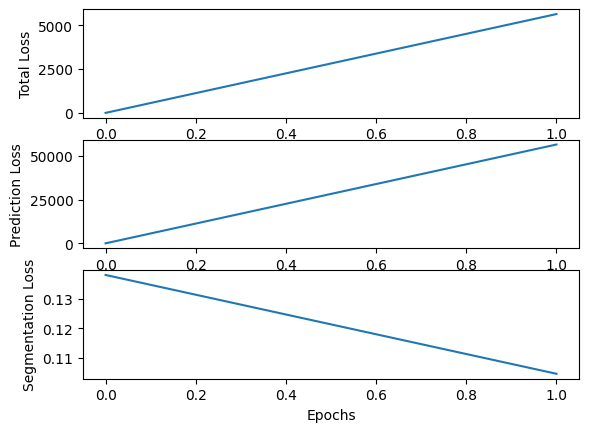

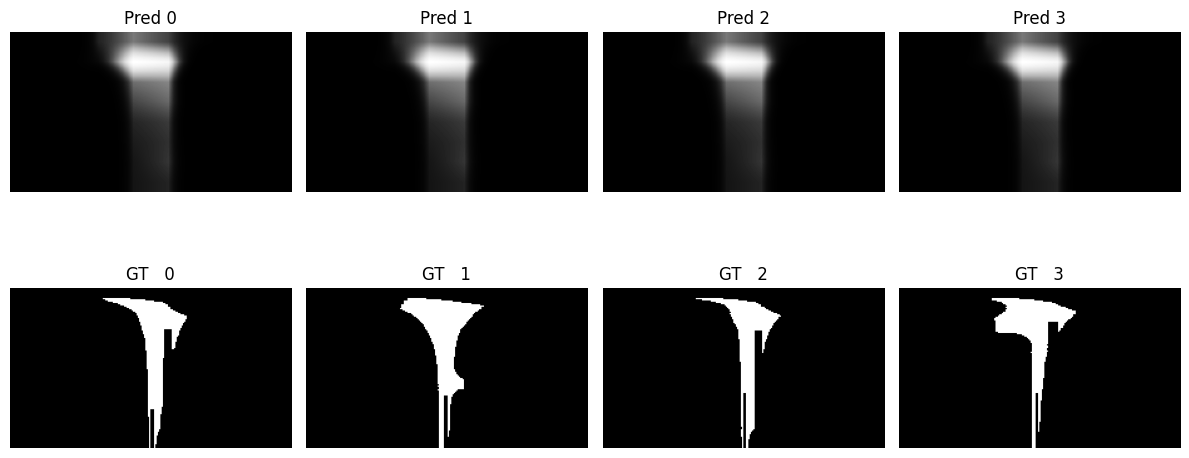

Epoch No 2


 38%|███▊      | 499/1315 [35:51<58:38,  4.31s/it]  


Epoch 003, Loss: 67657.0132
Epoch No 3


 38%|███▊      | 499/1315 [35:11<57:33,  4.23s/it]  


Epoch 004, Loss: 100994.6723
  → Saved checkpoint: checkpoints/state_prediction_run_1_segmentation\epoch_004.pth


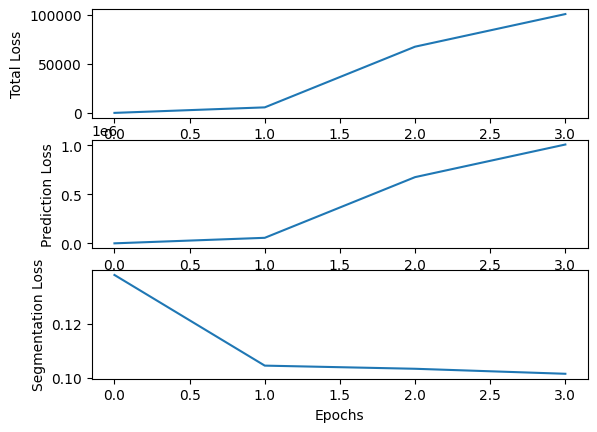

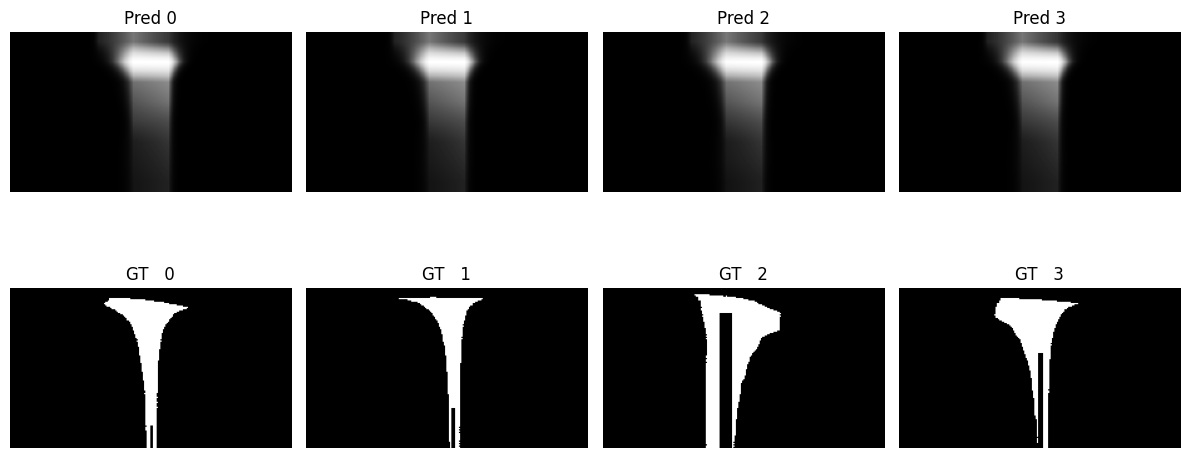

Epoch No 4


 38%|███▊      | 499/1315 [35:36<58:13,  4.28s/it]  


Epoch 005, Loss: 71410.8838
Epoch No 5


 38%|███▊      | 499/1315 [34:58<57:12,  4.21s/it]  


Epoch 006, Loss: 68431.8906
  → Saved checkpoint: checkpoints/state_prediction_run_1_segmentation\epoch_006.pth


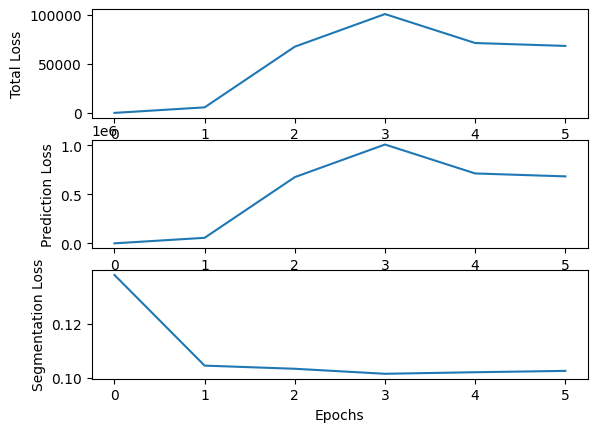

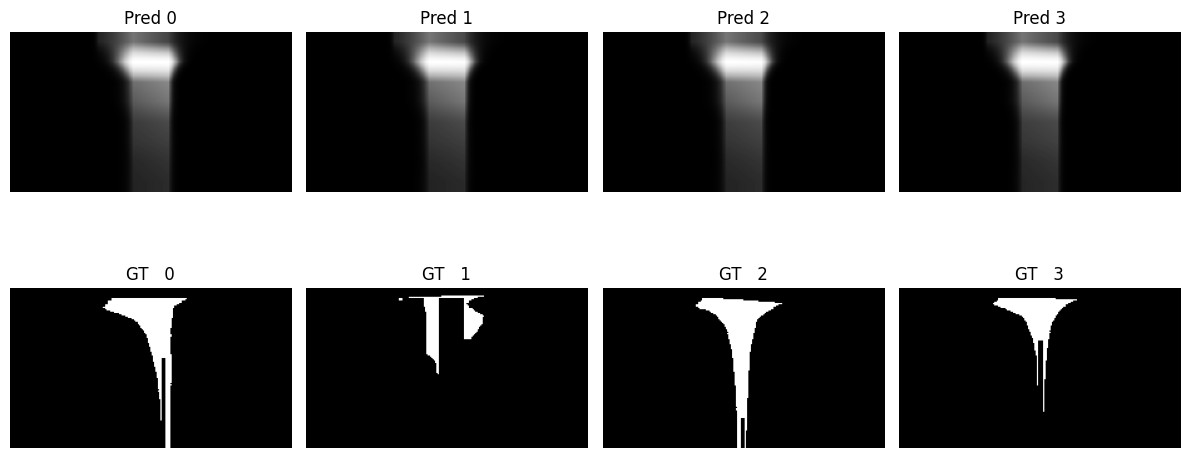

Epoch No 6


 38%|███▊      | 499/1315 [35:03<57:19,  4.22s/it]  


Epoch 007, Loss: 58661.3537
Epoch No 7


 38%|███▊      | 499/1315 [35:00<57:15,  4.21s/it]  


Epoch 008, Loss: 42834.7365
  → Saved checkpoint: checkpoints/state_prediction_run_1_segmentation\epoch_008.pth


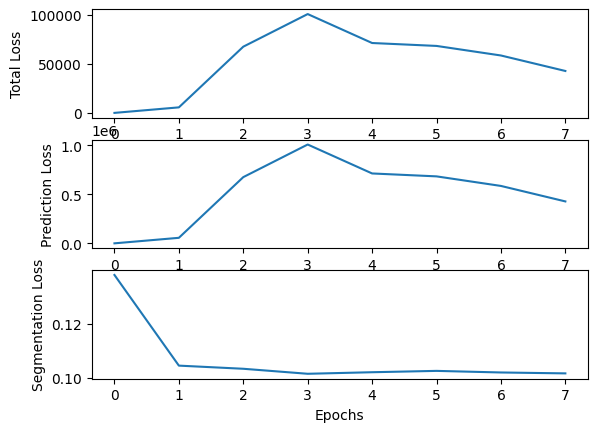

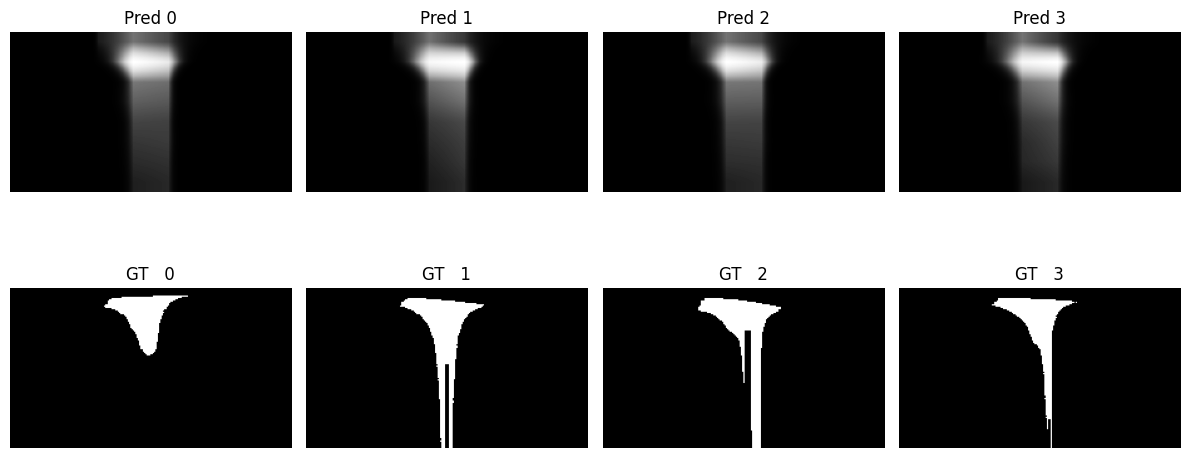

Epoch No 8


 38%|███▊      | 499/1315 [35:05<57:22,  4.22s/it]  


Epoch 009, Loss: 92189.8475
Epoch No 9


 38%|███▊      | 499/1315 [34:49<56:56,  4.19s/it]  


Epoch 010, Loss: 61191.5188
  → Saved checkpoint: checkpoints/state_prediction_run_1_segmentation\epoch_010.pth


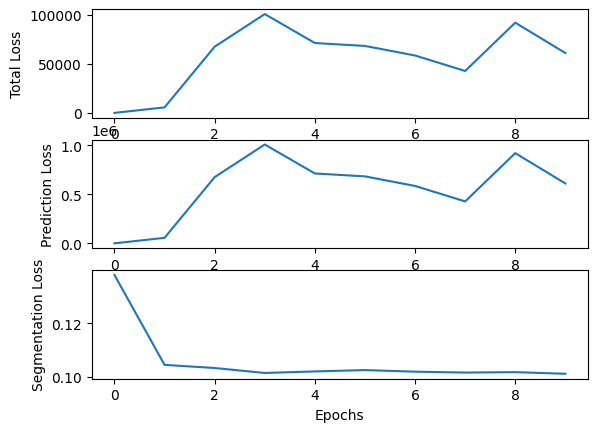

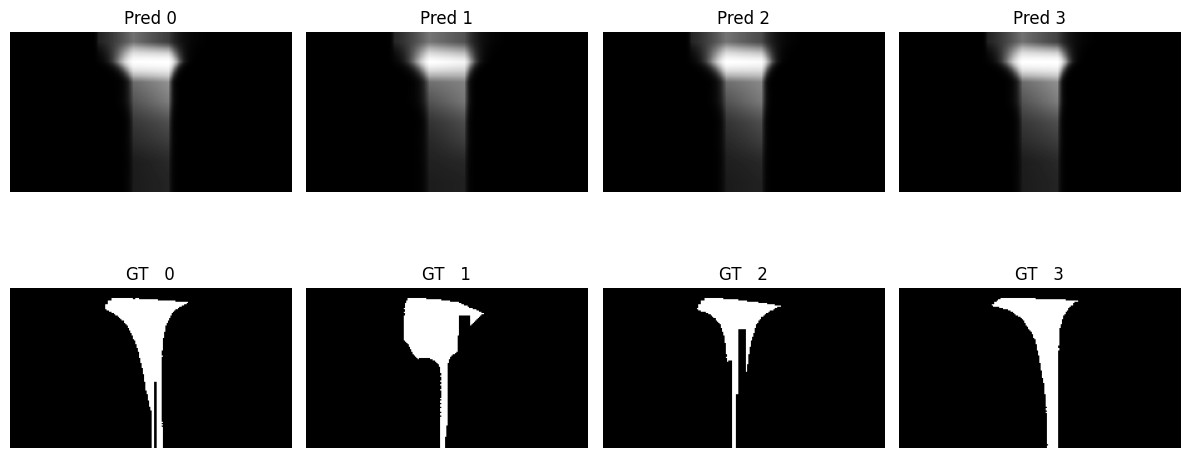

Epoch No 10


 38%|███▊      | 499/1315 [35:57<58:48,  4.32s/it]  


Epoch 011, Loss: 60711.1517
Epoch No 11


 38%|███▊      | 499/1315 [35:18<57:44,  4.25s/it]  


Epoch 012, Loss: 105473.8157
  → Saved checkpoint: checkpoints/state_prediction_run_1_segmentation\epoch_012.pth


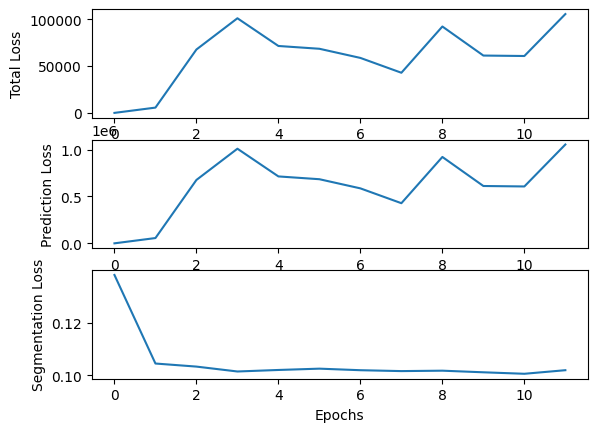

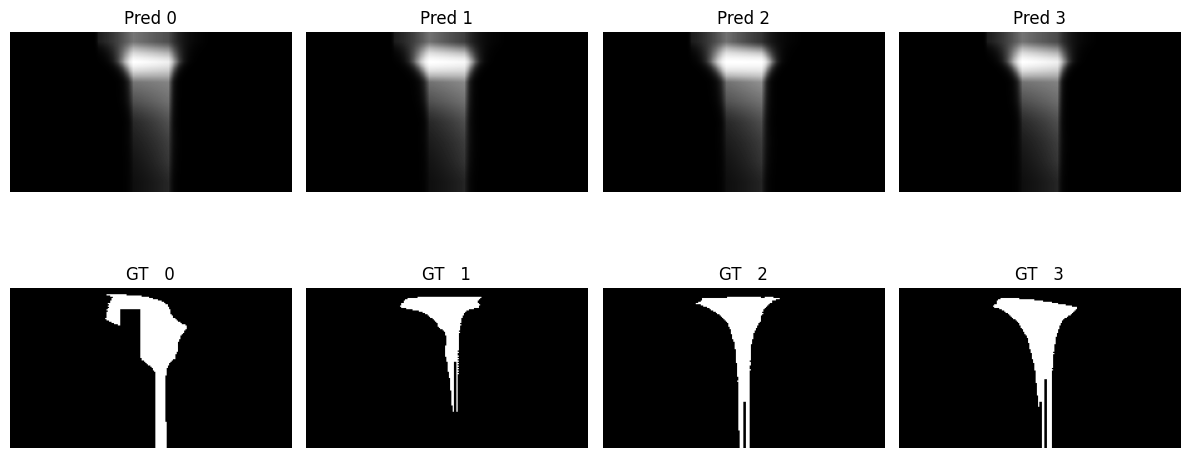

Epoch No 12


 38%|███▊      | 499/1315 [35:39<58:18,  4.29s/it]  


Epoch 013, Loss: 71153.4587
Epoch No 13


 38%|███▊      | 499/1315 [34:56<57:09,  4.20s/it]  


Epoch 014, Loss: 68774.1452
  → Saved checkpoint: checkpoints/state_prediction_run_1_segmentation\epoch_014.pth


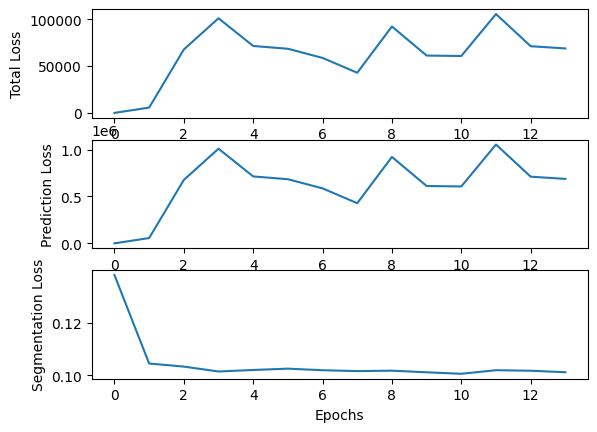

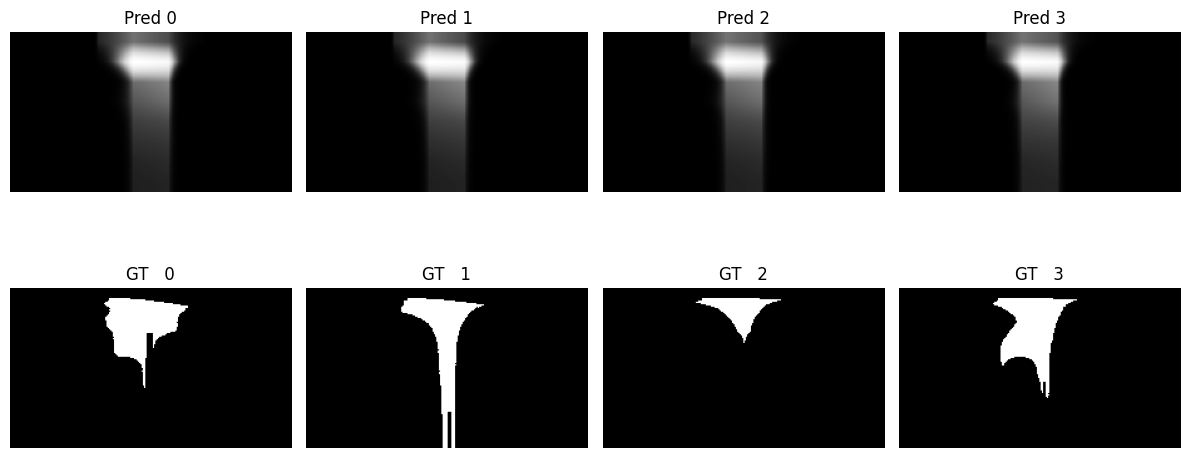

Epoch No 14


 38%|███▊      | 499/1315 [35:07<57:26,  4.22s/it]  


Epoch 015, Loss: 76498.9271
Epoch No 15


 38%|███▊      | 499/1315 [35:04<57:21,  4.22s/it]  


Epoch 016, Loss: 139179.8085
  → Saved checkpoint: checkpoints/state_prediction_run_1_segmentation\epoch_016.pth


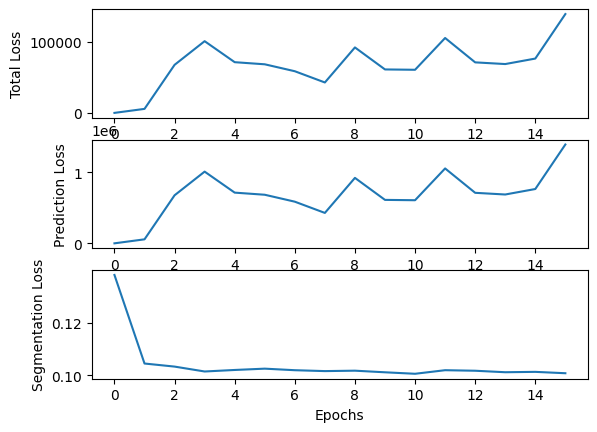

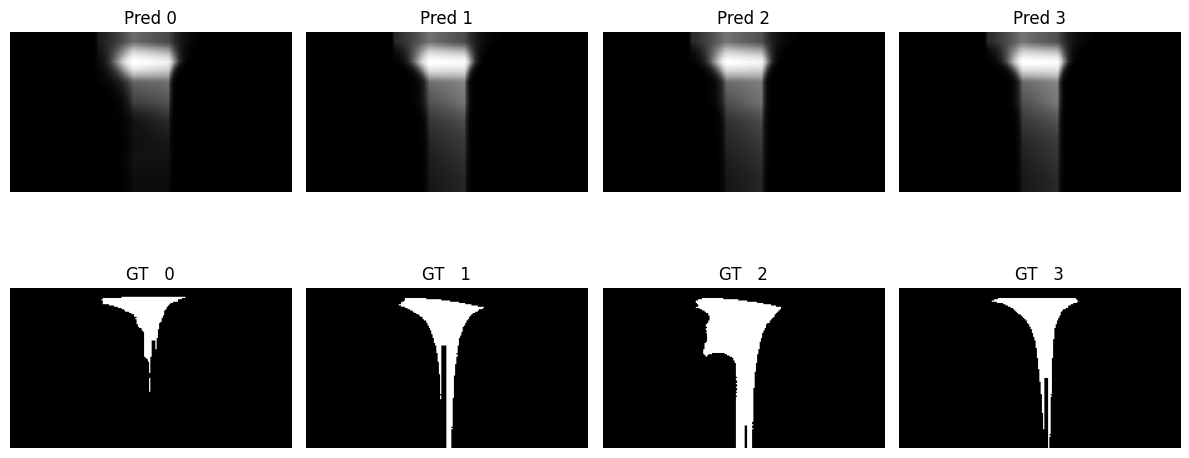

Epoch No 16


 38%|███▊      | 499/1315 [36:07<59:04,  4.34s/it]  


Epoch 017, Loss: 99297.4486
Epoch No 17


 38%|███▊      | 499/1315 [34:25<56:17,  4.14s/it]  


Epoch 018, Loss: 109965.9599
  → Saved checkpoint: checkpoints/state_prediction_run_1_segmentation\epoch_018.pth


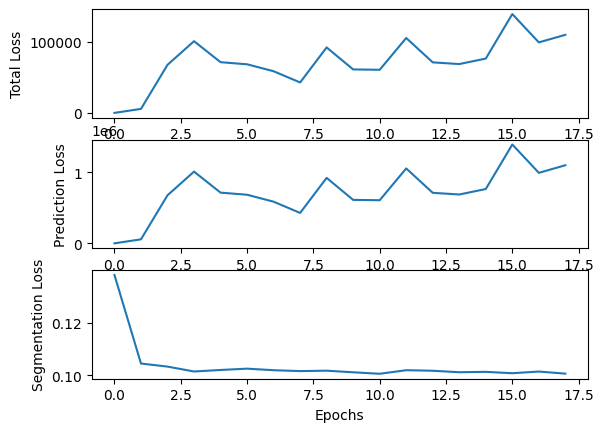

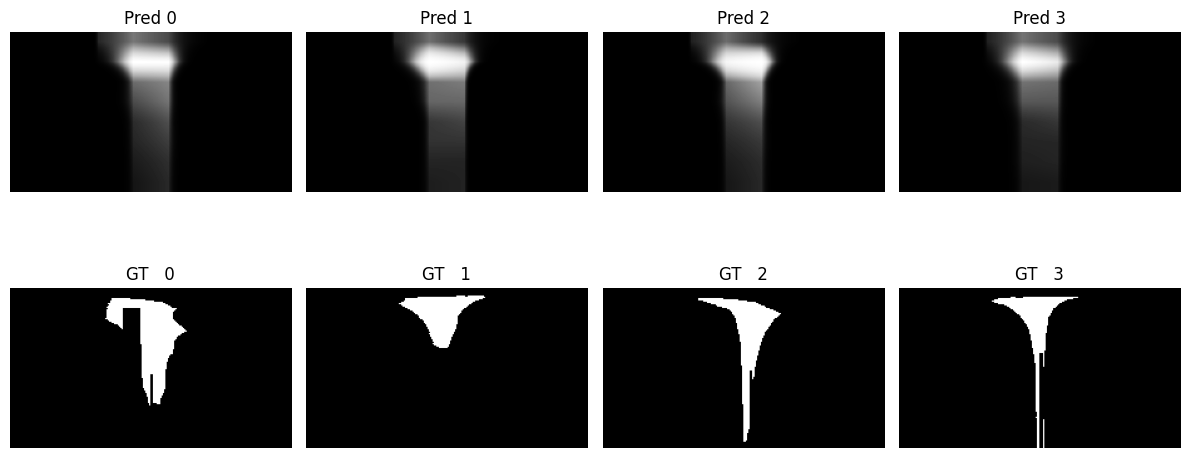

Epoch No 18


 38%|███▊      | 499/1315 [36:24<59:32,  4.38s/it]  


Epoch 019, Loss: 45934.5820
Epoch No 19


 38%|███▊      | 499/1315 [36:31<59:43,  4.39s/it]  


Epoch 020, Loss: 82279.4864
  → Saved checkpoint: checkpoints/state_prediction_run_1_segmentation\epoch_020.pth


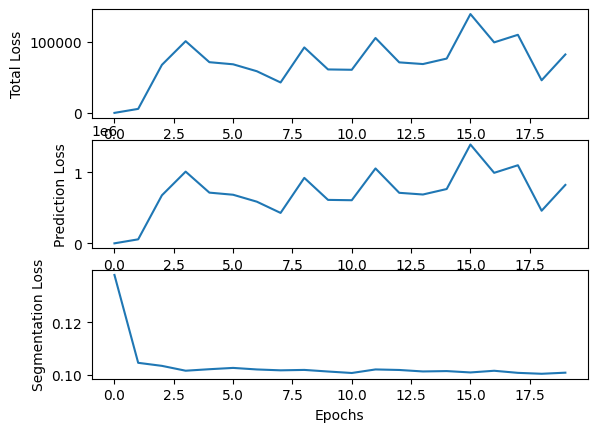

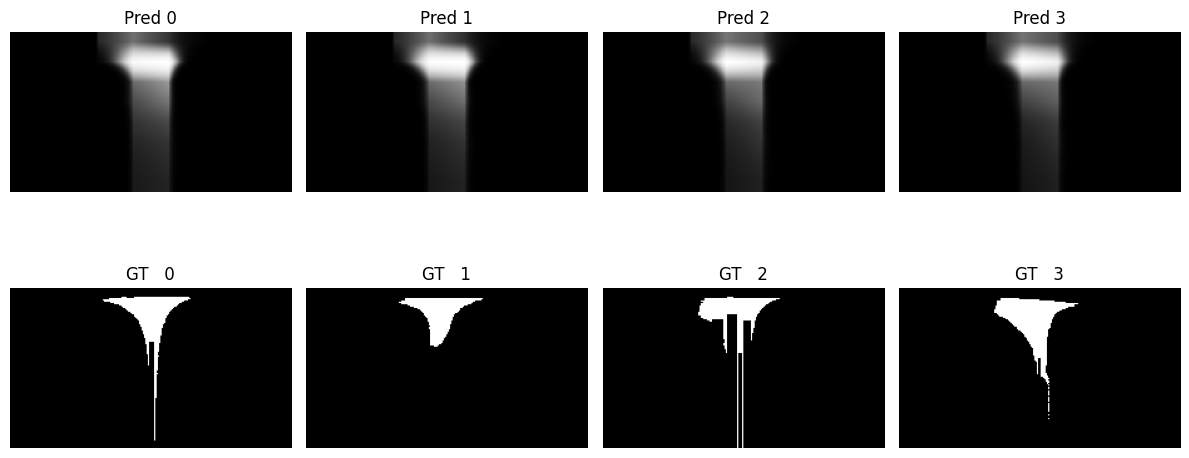

Epoch No 20


 38%|███▊      | 499/1315 [37:41<1:01:37,  4.53s/it]


Epoch 021, Loss: 96285.5632
Epoch No 21


 38%|███▊      | 499/1315 [37:06<1:00:40,  4.46s/it]


Epoch 022, Loss: 159728.8778
  → Saved checkpoint: checkpoints/state_prediction_run_1_segmentation\epoch_022.pth


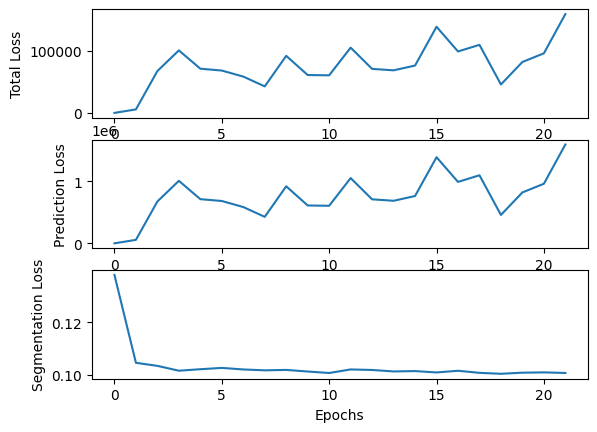

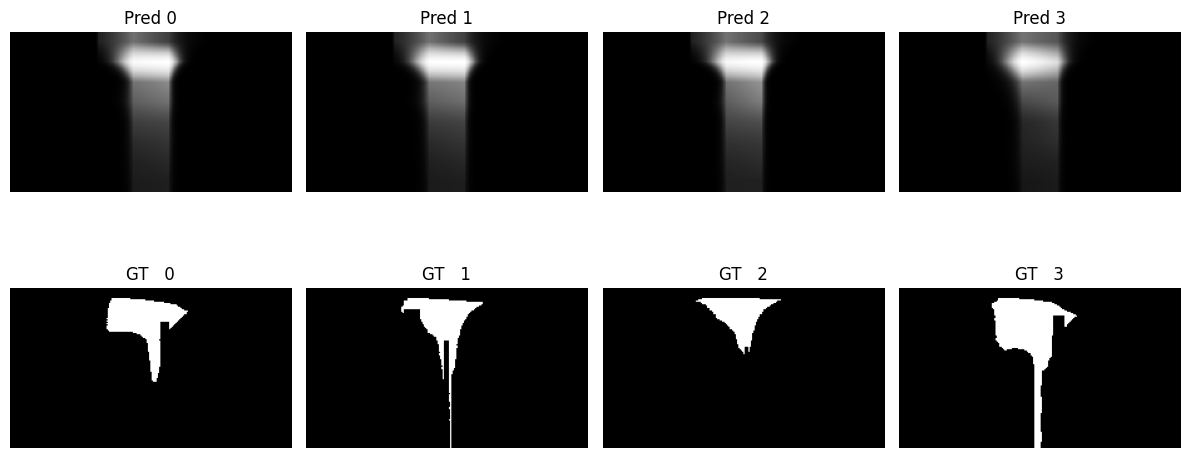

Epoch No 22


 38%|███▊      | 499/1315 [37:12<1:00:51,  4.47s/it]


Epoch 023, Loss: 73080.0590
Epoch No 23


 38%|███▊      | 499/1315 [37:39<1:01:35,  4.53s/it]


Epoch 024, Loss: 73114.9932
  → Saved checkpoint: checkpoints/state_prediction_run_1_segmentation\epoch_024.pth


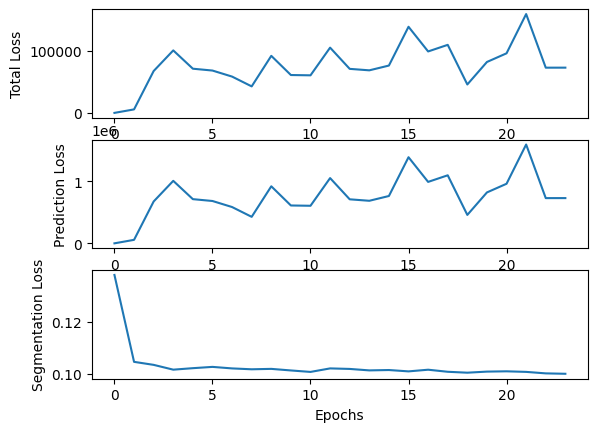

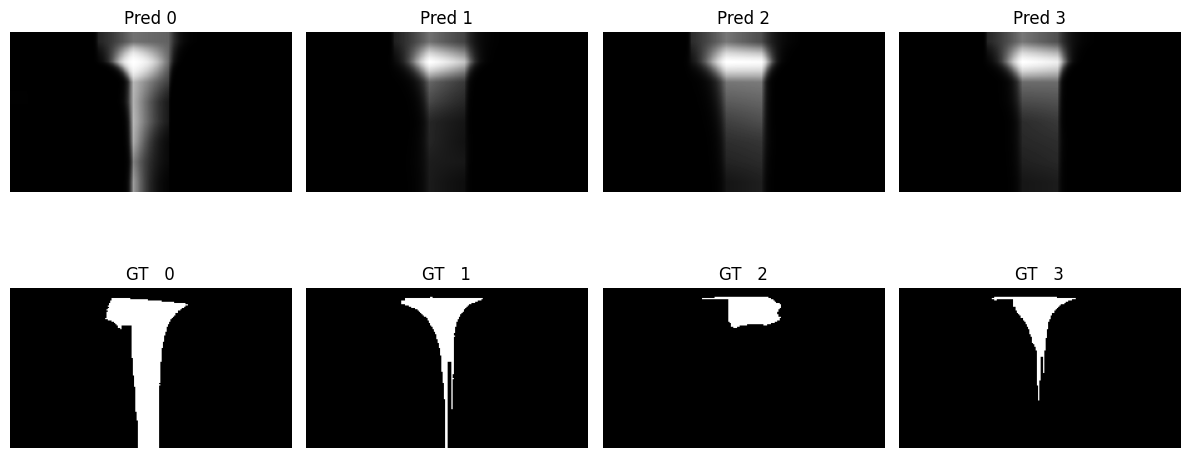

Epoch No 24


 38%|███▊      | 499/1315 [36:52<1:00:18,  4.43s/it]


Epoch 025, Loss: 77271.9032
Epoch No 25


 38%|███▊      | 499/1315 [36:44<1:00:05,  4.42s/it]


Epoch 026, Loss: 66538.9001
  → Saved checkpoint: checkpoints/state_prediction_run_1_segmentation\epoch_026.pth


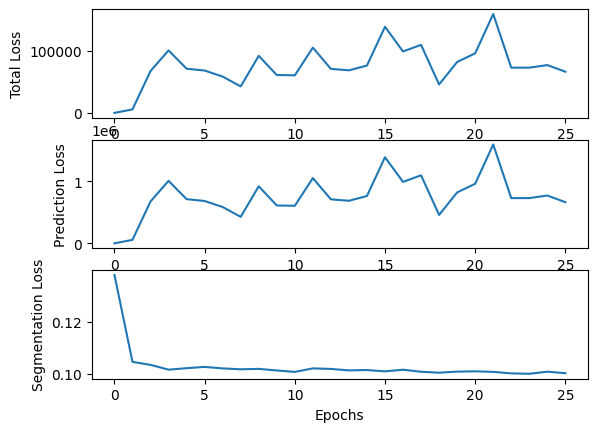

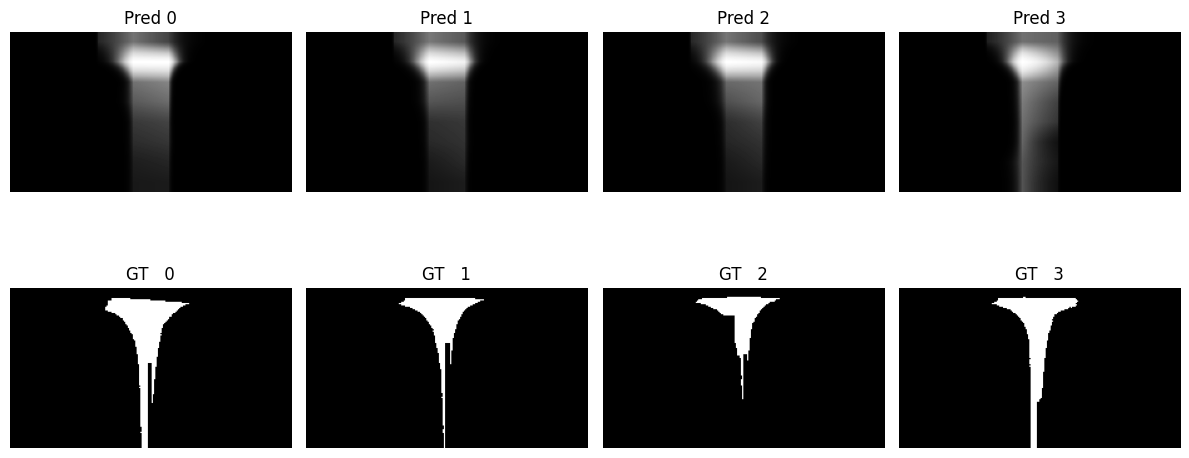

Epoch No 26


 38%|███▊      | 499/1315 [37:21<1:01:05,  4.49s/it]


Epoch 027, Loss: 60975.3846
Epoch No 27


 36%|███▌      | 476/1315 [35:00<1:01:42,  4.41s/it]


KeyboardInterrupt: 

In [9]:
import os
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

device = 'cuda'

batch_size = 8
num_epochs = 200
checkpoint_frequency = 2
plot_frequency = 2
ckpt_dir   = "checkpoints/state_prediction_run_1_segmentation"
os.makedirs(ckpt_dir, exist_ok=True)

if __name__ == "__main__":


    predictor_model  = StatePredictor(128, 256, 2).to(device)
    state_encoder    = FastRadarSSMEncoder().to(device)
    target_encoder   = FastRadarSSMEncoder().to(device)
    seg_decoder      = SSMDecoder(state_dim=128, hidden_dim=256,
                              out_h=128, out_w=225).to(device)

    
    target_encoder.load_state_dict(state_encoder.state_dict())
    for p in target_encoder.parameters():
        p.requires_grad = False

    optimizer_pred   = optim.Adam(predictor_model.parameters(),   lr=1e-3)
    optimizer_enc    = optim.Adam(state_encoder.parameters(),     lr=1e-3)
    optimizer_dec    = optim.Adam(seg_decoder.parameters(), 1e-3)
    rmse_loss        = nn.MSELoss()
    seg_loss  = nn.BCEWithLogitsLoss()


    predictor_model.train()
    state_encoder.train()
    seg_decoder.train()

    epoch_losses = []
    epoch_losses_pred = []
    epoch_losses_seg = []

    for epoch in range(num_epochs):
        print(f"Epoch No {epoch}")
        epoch_loss = 0.0
        epoch_loss_pred = 0.0
        epoch_loss_seg = 0.0
        batch_no = 0
        last_pred_masks = None
        last_gt_masks   = None

        # --- Example usage ---
        for batch in tqdm(dataloader):
            batch_no += 1
            radar_batch = batch["radar"].to(device)       # [B, C', H, W]
            target_batch = batch["radar_next"].to(device)
            mask_batch   = batch["mask"].to(device)      # [B, 1, H, W]
            # … your training / evaluation logic …

            output, cur_state   = state_encoder(radar_batch)
            with torch.no_grad():
                _, next_state = target_encoder(target_batch)

            pred_state = predictor_model(cur_state)
            loss_rmse = rmse_loss(pred_state, next_state[:, -1, :])

            mask_logits = seg_decoder(output)
            loss_seg = seg_loss(mask_logits, mask_batch)

            beta = 0.1

            loss = beta*loss_rmse + loss_seg

            optimizer_pred.zero_grad()
            optimizer_enc.zero_grad()
            optimizer_dec.zero_grad()
            loss.backward()
            optimizer_pred.step()
            optimizer_enc.step()
            optimizer_dec.step()

            epoch_loss += loss.item()
            epoch_loss_pred += loss_rmse.item()
            epoch_loss_seg += loss_seg.item()

            if batch_no == 500:
                break

        with torch.no_grad():
            last_pred_masks = torch.sigmoid(mask_logits).cpu()
            last_gt_masks   = mask_batch.cpu()

        print(f"Epoch {epoch+1:03d}, Loss: {epoch_loss/batch_no:.4f}")
        epoch_losses.append(epoch_loss/batch_no)
        epoch_losses_pred.append(epoch_loss_pred/batch_no)
        epoch_losses_seg.append(epoch_loss_seg/batch_no)
        # hard-sync the target encoder
        target_encoder.load_state_dict(state_encoder.state_dict())

        # === checkpoint every some epochs ===
        if (epoch + 1) % checkpoint_frequency == 0:
            ckpt_path = os.path.join(ckpt_dir, f"epoch_{epoch+1:03d}.pth")
            torch.save({
                'epoch': epoch + 1,
                'state_encoder': state_encoder.state_dict(),
                'predictor_model': predictor_model.state_dict(),
                'segmentation_decoder': seg_decoder.state_dict(),
                'optimizer_enc': optimizer_enc.state_dict(),
                'optimizer_pred': optimizer_pred.state_dict(),
                'optimizer_dec': optimizer_dec.state_dict(),
                'loss': epoch_loss / batch_no,
            }, ckpt_path)
            print(f"  → Saved checkpoint: {ckpt_path}")

        if(epoch+1)% plot_frequency == 0:
            plt.figure()
            plt.subplot(311), plt.plot(np.array(epoch_losses)), plt.ylabel("Total Loss")
            plt.subplot(312), plt.plot(np.array(epoch_losses_pred)), plt.ylabel("Prediction Loss")
            plt.subplot(313), plt.plot(np.array(epoch_losses_seg)), plt.ylabel("Segmentation Loss")
            plt.xlabel("Epochs")
            plt.show()

            if last_pred_masks is not None:
                fig, axes = plt.subplots(2, 4, figsize=(12, 6))
                for i in range(4):
                    # Predicted mask
                    axes[0, i].imshow(last_pred_masks[i, 0], cmap='gray')
                    axes[0, i].set_title(f'Pred {i}')
                    axes[0, i].axis('off')
                    # Ground-truth mask
                    axes[1, i].imshow(last_gt_masks[i, 0], cmap='gray')
                    axes[1, i].set_title(f'GT   {i}')
                    axes[1, i].axis('off')
                plt.tight_layout()
                plt.show()


#### State Prediction Training Outputs

In [36]:
number_samples = 8

with torch.no_grad():

    radar_list, target_list = [], []
    image_list = []

    idxs = np.random.choice(len(seq_dirs_sorted), size=number_samples, replace=False)
    
    for i in idxs:
        seq = seq_dirs_sorted[i]
        db = SyncReader(f"data_raw_sequences/{seq}", silent=True)
        N  = len(db) - 1
    
        sample_no = np.random.randint(len(db)-1)

        radar_list.append( get_radar_cube(db.GetSensorData(sample_no )) )
        target_list.append(get_radar_cube(db.GetSensorData(sample_no+1)))
        image_list.append(db.GetSensorData(i)['camera']['data'])

    radar_batch  = torch.from_numpy(np.stack(radar_list, 0).astype(np.float32)).to(device)
    target_batch = torch.from_numpy(np.stack(target_list,0).astype(np.float32)).to(device)

    _, cur_state   = state_encoder(radar_batch)

    _, next_state = target_encoder(target_batch)

    pred_state = predictor_model(cur_state)
    loss = criterion(pred_state, next_state)



In [ ]:
for idx in range(number_samples):
    plt.figure()
    plt.imshow(image_list[idx])
    plt.show()

    plt.figure()
    plt.subplot(411), plt.plot(cur_state.cpu().numpy()[idx, :]), plt.ylabel('s_0')
    plt.subplot(412), plt.plot(next_state.cpu().numpy()[idx, :]), plt.ylabel('s_1')
    plt.subplot(413), plt.plot(pred_state.cpu().numpy()[idx, :]), plt.ylabel('se_1')
    plt.subplot(414), plt.plot(next_state.cpu().numpy()[idx, :]-pred_state.cpu().numpy()[idx, :]), plt.ylabel('e_1')
    plt.show()

### Experiment Conclusion

Things done in this experiment:

1. I am now trying to find segmentation maps alongside the state prediction. Segmentation map is generated from the output of the ssm while the predictions are generated from state. No particular reason actually. Also doing some predefined normalization for the radar data.